## Step 1: Data Preprocessing

In [3]:
BUILD95 = True

import numpy as np, pandas as pd, gc
import matplotlib.pyplot as plt
import seaborn as sns

# COLUMNS WITH STRINGS
str_type = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
str_type += ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']

# FIRST 53 COLUMNS
cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

In [4]:
df = pd.read_csv('data/train_transaction.csv', index_col='TransactionID', dtype=dtypes, usecols=cols+['isFraud'])
df_identity = pd.read_csv('data/train_identity.csv',index_col='TransactionID', dtype=dtypes)
df = df.merge(df_identity, how='left', left_index=True, right_index=True)

In [5]:
df

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,0,86400.0,68.500000,W,13926.0,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001.0,0,86401.0,29.000000,W,2755.0,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002.0,0,86469.0,59.000000,W,4663.0,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003.0,0,86499.0,50.000000,W,18132.0,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004.0,0,86506.0,50.000000,H,4497.0,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,0,15811047.0,49.000000,W,6550.0,NaN,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577536.0,0,15811049.0,39.500000,W,10444.0,225.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577537.0,0,15811079.0,30.950001,W,12037.0,595.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
from sklearn.model_selection import train_test_split
# First, create stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('isFraud', axis=1), 
    df['isFraud'], 
    test_size=0.2, 
    stratify=df['isFraud'],  # Maintain fraud ratio in both splits
    random_state=42
)


print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

total_samples = df.shape[0]

# Calculate ratios
train_ratio = X_train.shape[0] / total_samples * 100
test_ratio = X_test.shape[0] / total_samples * 100

# Print ratios
print(f'Train %: {train_ratio}')
print(f'Test %: {test_ratio}')
# Check class distribution across all splits
print("\nClass distribution:")
print(f"Original:    Fraud: {df['isFraud'].mean():.4f}")
print(f"Train:       Fraud: {y_train.mean():.4f}")
print(f"Test:        Fraud: {y_test.mean():.4f}")

Train shape: (472432, 213)
Test shape: (118108, 213)
Train %: 80.0
Test %: 20.0

Class distribution:
Original:    Fraud: 0.0350
Train:       Fraud: 0.0350
Test:        Fraud: 0.0350


In [7]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3027809.0,1008491.0,100.000000,R,6177.0,399.0,150.0,american express,150.0,credit,264.0,...,ie 11.0 for desktop,24.0,1920x1080,match_status:2,T,F,T,T,desktop,Trident/7.0
3272886.0,7008212.0,29.990000,W,7900.0,345.0,150.0,mastercard,224.0,debit,143.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3091256.0,2071522.0,107.949997,W,11690.0,111.0,150.0,visa,226.0,credit,191.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3494860.0,13299752.0,241.949997,W,2616.0,327.0,150.0,discover,102.0,credit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3183382.0,4412283.0,117.000000,W,13780.0,298.0,150.0,visa,226.0,debit,441.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3311259.0,8019613.0,59.000000,W,10493.0,455.0,150.0,mastercard,126.0,debit,123.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3519790.0,14047023.0,20.903000,C,5595.0,545.0,185.0,visa,138.0,debit,NaN,...,chrome 66.0,NaN,NaN,NaN,F,F,T,F,desktop,NaN
3016747.0,754797.0,400.000000,W,9335.0,373.0,150.0,visa,226.0,debit,177.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# NORMALIZE D COLUMNS
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
    X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60) 

In [9]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name] = train_df[new_col_name].fillna(-1)
                    test_df[new_col_name] = test_df[new_col_name].fillna(-1)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

In [10]:
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 'D9_card1_mean' , 'D9_card1_std' , 'D9_card1_addr1_mean' , 'D9_card1_addr1_std' , 'D9_card1_addr1_P_emaildomain_mean' , 'D9_card1_addr1_P_emaildomain_std' , 'D11_card1_mean' , 'D11_card1_std' , 'D11_card1_addr1_mean' , 'D11_card1_addr1_std' , 'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , 

In [11]:
%%time
# LABEL ENCODE AND MEMORY REDUCE
for i,f in enumerate(X_train.columns):
    # FACTORIZE CATEGORICAL VARIABLES
    if (np.str_(X_train[f].dtype)=='category')|(X_train[f].dtype=='object'): 
        df_comb = pd.concat([X_train[f],X_test[f]],axis=0)
        df_comb,_ = df_comb.factorize(sort=True)
        if df_comb.max()>32000: print(f,'needs int32')
        X_train[f] = df_comb[:len(X_train)].astype('int16')
        X_test[f] = df_comb[len(X_train):].astype('int16')
    # SHIFT ALL NUMERICS POSITIVE. SET NAN to -1
    elif f not in ['TransactionAmt','TransactionDT']:
        mn = np.min((X_train[f].min(),X_test[f].min()))
        X_train[f] -= np.float32(mn)
        X_test[f] -= np.float32(mn)
        X_train[f] = X_train[f].fillna(-1)
        X_test[f] = X_test[f].fillna(-1)

CPU times: total: 1.41 s
Wall time: 1.4 s


In [13]:
import datetime
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_train['DT_M'] = (X_train['DT_M'].dt.year-2017)*12 + X_train['DT_M'].dt.month 

X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_test['DT_M'] = (X_test['DT_M'].dt.year-2017)*12 + X_test['DT_M'].dt.month 

In [15]:
X_train['day'] = X_train.TransactionDT / (24*60*60)
X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)

X_test['day'] = X_test.TransactionDT / (24*60*60)
X_test['uid'] = X_test.card1_addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

In [17]:
%%time
# FREQUENCY ENCODE UID
encode_FE(X_train,X_test,['uid'])
# AGGREGATE 
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
# AGGREGATE
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
# AGGREGATE
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREGATE
encode_AG(['C14'],['uid'],['std'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE 
encode_AG2(['C13','V314'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREATE 
encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train, test_df=X_test)
# NEW FEATURE
X_train['outsider15'] = (np.abs(X_train.D1-X_train.D15)>3).astype('int8')
X_test['outsider15'] = (np.abs(X_test.D1-X_test.D15)>3).astype('int8')
print('outsider15')

uid_FE , 'TransactionAmt_uid_mean' , 'TransactionAmt_uid_std' , 'D4_uid_mean' , 'D4_uid_std' , 'D9_uid_mean' , 'D9_uid_std' , 'D10_uid_mean' , 'D10_uid_std' , 'D15_uid_mean' , 'D15_uid_std' , 'C1_uid_mean' , 'C2_uid_mean' , 'C4_uid_mean' , 'C5_uid_mean' , 'C6_uid_mean' , 'C7_uid_mean' , 'C8_uid_mean' , 'C9_uid_mean' , 'C10_uid_mean' , 'C11_uid_mean' , 'C12_uid_mean' , 'C13_uid_mean' , 'C14_uid_mean' , 'M1_uid_mean' , 'M2_uid_mean' , 'M3_uid_mean' , 'M4_uid_mean' , 'M5_uid_mean' , 'M6_uid_mean' , 'M7_uid_mean' , 'M8_uid_mean' , 'M9_uid_mean' , uid_P_emaildomain_ct, uid_dist1_ct, uid_DT_M_ct, uid_id_02_ct, uid_cents_ct, 'C14_uid_std' , uid_C13_ct, uid_V314_ct, uid_V127_ct, uid_V136_ct, uid_V309_ct, uid_V307_ct, uid_V320_ct, outsider15
CPU times: total: 36.2 s
Wall time: 36.3 s


In [18]:
cols = list(X_train.columns)
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['DT_M','day','uid']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [19]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 263 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

In [20]:
X_train_val, X_holdout, y_train_val, y_holdout = train_test_split(
    X_train, y_train,
    test_size=0.1875,  # 18.75% for the holdout set
    stratify=y_train,  # Maintain class distribution
    random_state=42
)

# Step 2: Split train+val into train (62.5%) and validation (18.75%)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2308,  # 18.75% of the total dataset, i.e., 25% of the 81.25%
    stratify=y_train_val,  # Maintain class distribution
    random_state=42
)

## Step 2: Hyperparameter Tuning

In [28]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import time

def objective(trial):
    """Optuna objective function for hyperparameter optimization"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'missing': -1,
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'random_state': 42,
        'early_stopping_rounds': 30,
        'n_jobs': -1
    }

    # 5-fold stratified cross-validation on TRAINING SET ONLY
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Create fold splits
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Train model on fold
        clf_fold = xgb.XGBClassifier(**params)
        clf_fold.fit(
            X_fold_train[cols], y_fold_train,
            eval_set=[(X_fold_val[cols], y_fold_val)],
            verbose=False
        )

        # Evaluate on fold validation set
        y_pred_proba = clf_fold.predict_proba(X_fold_val[cols])[:, 1]
        fold_score = roc_auc_score(y_fold_val, y_pred_proba)
        cv_scores.append(fold_score)
    training_time = time.time() - start_time

    # Return average CV score
    return np.mean(cv_scores), -training_time

# Run Optuna optimization
print("Starting hyperparameter optimization...")
study = optuna.create_study(
    directions=['maximize', 'minimize'],
    sampler=optuna.samplers.TPESampler(seed=43, n_startup_trials=3),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1)
)

# Optimize (adjust n_trials based on your computational budget)
study.optimize(objective, n_trials=100, timeout=7200)
# Get best trials for multi-objective optimization
print(f"\nHyperparameter optimization completed!")
print(f"Number of completed trials: {len(study.trials)}")

# Get Pareto optimal solutions
best_trials = study.best_trials
print(f"\nNumber of optimal solutions: {len(best_trials)}")

print("\nOptimal Hyperparameter:")
for i, trial in enumerate(best_trials):
    print(f"\nSolution {i+1}:")
    print(f"  AUC Score: {trial.values[0]:.4f}")
    print(f"  Training Time: {-trial.values[1]:.2f} seconds")
    print(f"  Parameters:")
    for param, value in trial.params.items():
        print(f"    {param}: {value}")

[I 2025-08-11 16:26:21,089] A new study created in memory with name: no-name-a8abbf5a-e6c3-43ac-bfca-7e9cc827ef0c


Starting hyperparameter optimization...


[I 2025-08-11 16:32:33,566] Trial 0 finished with values: [0.9726462793670937, -372.4178023338318] and parameters: {'n_estimators': 492, 'max_depth': 8, 'learning_rate': 0.060156057679655414, 'subsample': 0.7481179239930698, 'colsample_bytree': 0.36542781116222794, 'reg_alpha': 4.436549963794391, 'reg_lambda': 1.4991353196470385}.
[I 2025-08-11 16:41:40,473] Trial 1 finished with values: [0.9716441936767538, -546.8420763015747] and parameters: {'n_estimators': 833, 'max_depth': 5, 'learning_rate': 0.13827080689661556, 'subsample': 0.7789900036862012, 'colsample_bytree': 0.4604094237257333, 'reg_alpha': 2.017684503439517, 'reg_lambda': 0.5853274049767276}.
[I 2025-08-11 16:54:46,533] Trial 2 finished with values: [0.9736199474565259, -786.0056681632996] and parameters: {'n_estimators': 1094, 'max_depth': 6, 'learning_rate': 0.08765928983226415, 'subsample': 0.7632192942036418, 'colsample_bytree': 0.31533253999928945, 'reg_alpha': 4.372898776918818, 'reg_lambda': 1.7734087216172922}.
[I 


Hyperparameter optimization completed!
Number of completed trials: 13

Number of optimal solutions: 7

Optimal Hyperparameter:

Solution 1:
  AUC Score: 0.9736
  Training Time: 786.01 seconds
  Parameters:
    n_estimators: 1094
    max_depth: 6
    learning_rate: 0.08765928983226415
    subsample: 0.7632192942036418
    colsample_bytree: 0.31533253999928945
    reg_alpha: 4.372898776918818
    reg_lambda: 1.7734087216172922

Solution 2:
  AUC Score: 0.9689
  Training Time: 858.28 seconds
  Parameters:
    n_estimators: 1190
    max_depth: 5
    learning_rate: 0.0811999835663092
    subsample: 0.8986096356476417
    colsample_bytree: 0.30481571582885936
    reg_alpha: 4.928772590254789
    reg_lambda: 1.995592107269129

Solution 3:
  AUC Score: 0.9758
  Training Time: 457.53 seconds
  Parameters:
    n_estimators: 1167
    max_depth: 10
    learning_rate: 0.08710310839859778
    subsample: 0.8978312047834626
    colsample_bytree: 0.3039349838575605
    reg_alpha: 4.922116134058799
   

In [43]:
best_params = best_trials[0].params
best_params

{'n_estimators': 1094,
 'max_depth': 6,
 'learning_rate': 0.08765928983226415,
 'subsample': 0.7632192942036418,
 'colsample_bytree': 0.31533253999928945,
 'reg_alpha': 4.372898776918818,
 'reg_lambda': 1.7734087216172922}

In [116]:
import json
from pathlib import Path

# Create a list of best trial results
results = []
for trial in best_trials:
    results.append({
        "AUC_Score": trial.values[0],
        "Training_Time": -trial.values[1],
        "Parameters": trial.params
    })

# Save to JSON file
output_path = Path("best_hyperparams.json")
with open(output_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Best hyperparameters saved to {output_path}")

Best hyperparameters saved to best_hyperparams.json


## Step 3: Model Training

In [44]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

if BUILD95:
    clf = xgb.XGBClassifier( 
        **best_params,
        missing=-1, 
        eval_metric='auc',
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=100
    )

    # Fit the model with validation set and early stopping using eval_metric
    h = clf.fit(
        X_train_final[cols], y_train_final, 
        eval_set=[(X_val[cols], y_val)],  # Use proper validation set
        verbose=50,
    )

XGBoost version: 3.0.3
[0]	validation_0-auc:0.78008
[50]	validation_0-auc:0.92042
[100]	validation_0-auc:0.93639
[150]	validation_0-auc:0.94465
[200]	validation_0-auc:0.95037
[250]	validation_0-auc:0.95445
[300]	validation_0-auc:0.95730
[350]	validation_0-auc:0.95933
[400]	validation_0-auc:0.96110
[450]	validation_0-auc:0.96294
[500]	validation_0-auc:0.96422
[550]	validation_0-auc:0.96515
[600]	validation_0-auc:0.96593
[650]	validation_0-auc:0.96659
[700]	validation_0-auc:0.96721
[750]	validation_0-auc:0.96804
[800]	validation_0-auc:0.96842
[850]	validation_0-auc:0.96903
[900]	validation_0-auc:0.96935
[950]	validation_0-auc:0.96965
[1000]	validation_0-auc:0.96979
[1050]	validation_0-auc:0.96996
[1093]	validation_0-auc:0.97004


In [107]:
print("Best iteration:", clf.best_iteration)
print("Best AUC score:", clf.best_score)

Best iteration: 1083
Best AUC score: 0.9700923957932039


In [117]:
import joblib
from pathlib import Path

# After training
model_path = Path("xgb_model.json")
clf.save_model(model_path)  
print(f"Model saved to {model_path}")

joblib_path = Path("xgb_model.pkl")
joblib.dump(clf, joblib_path)
print(f"Pickle model saved to {joblib_path}")

Model saved to xgb_model.json
Pickle model saved to xgb_model.pkl


## Step 4: Business Centric Model Evaluation and Threshold Optimization

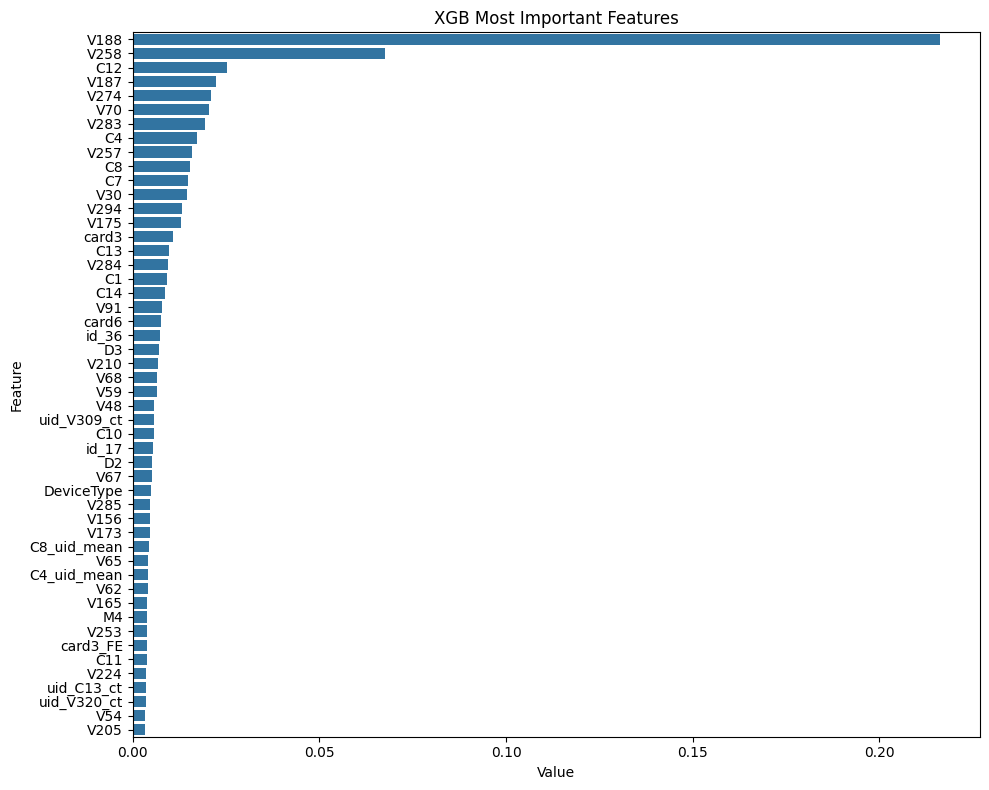

In [119]:
if BUILD95:

    feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
    plt.figure(figsize=(10, 8))
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
    plt.title('XGB Most Important Features')
    plt.tight_layout()
    plt.show()

In [65]:
from sklearn.metrics import roc_curve
y_proba_holdout = clf.predict_proba(X_holdout[cols])[:,1]
fpr, tpr, thresholds = roc_curve(y_holdout, y_proba_holdout)

In [115]:
cost_fp = 100   # cost of false alarm FPR (analysis cost + lost in customer trust)
cost_fn = 500   # cost of missed fraud FNR (direct financial loss)

total_negatives = np.sum(np.sum(y_holdout == 0))
total_positives = np.sum(np.sum(y_holdout == 1))

fn = (1 - tpr) * total_positives
fp = fpr * total_negatives

cost = (fp * cost_fp) + (fn * cost_fn)
min_cost_idx = np.argmin(cost)

print("Threshold minimizing cost:", thresholds[min_cost_idx])
best_threshold = thresholds[min_cost_idx]

Threshold minimizing cost: 0.12698609



BASELINE PERFORMANCE (threshold = 0.5)
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.95      0.69      0.80      4133

    accuracy                           0.99    118108
   macro avg       0.97      0.84      0.90    118108
weighted avg       0.99      0.99      0.99    118108

Baseline FPR: 0.1351%


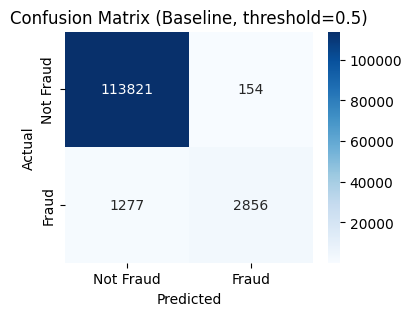

In [97]:
from sklearn.metrics import classification_report, confusion_matrix
y_test_proba = clf.predict_proba(X_test[cols])[:,1]
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

print("\n" + "="*50)
print("BASELINE PERFORMANCE (threshold = 0.5)")
print("="*50)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_default))
# Calculate baseline metrics
tn_base, fp_base, fn_base, tp_base = confusion_matrix(y_test, y_test_pred_default).ravel()
fpr_base = fp_base / (fp_base + tn_base)
print(f"Baseline FPR: {fpr_base*100:.4f}%")

cm = confusion_matrix(y_test, y_test_pred_default)

# Plot
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Baseline, threshold=0.5)')
plt.show()


OPTIMIZED PERFORMANCE (threshold = 0.1270)
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.74      0.84      0.79      4133

    accuracy                           0.98    118108
   macro avg       0.87      0.91      0.89    118108
weighted avg       0.99      0.98      0.98    118108

Optimized FPR: 1.0608%


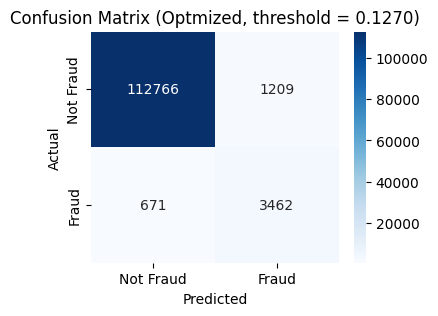

In [99]:
# Step 5: Final evaluation with optimized threshold
y_test_pred_optimized = (y_test_proba >= best_threshold).astype(int)

print("\n" + "="*50)
print(f"OPTIMIZED PERFORMANCE (threshold = {best_threshold:.4f})")
print("="*50)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_optimized))

# Calculate optimized metrics
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_test_pred_optimized).ravel()
fpr_opt = fp_opt / (fp_opt + tn_opt)
print(f"Optimized FPR: {fpr_opt*100:.4f}%")

cm = confusion_matrix(y_test, y_test_pred_optimized)

# Plot
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Optmized, threshold = {best_threshold:.4f})')
plt.show()

In [80]:
cost_baseline = (fp_base * cost_fp) + (fn_base * cost_fn)
cost_optimized = (fp_opt * cost_fp) + (fn_opt * cost_fn)
cost_savings = cost_baseline - cost_optimized

print(f"Baseline cost:  ${cost_baseline:,.2f}")
print(f"Optimized cost: ${cost_optimized:,.2f}")
print(f"Cost savings:   ${cost_savings:,.2f}")
print(f"Improvement:    {(cost_savings/cost_baseline)*100:.1f}%")

Baseline cost:  $653,900.00
Optimized cost: $456,400.00
Cost savings:   $197,500.00
Improvement:    30.2%


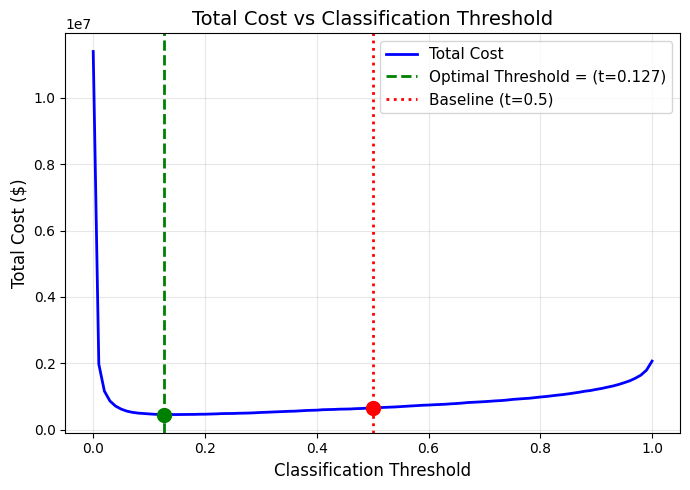

In [112]:
# Create a range of thresholds from 0 to 1
thresholds_range = np.linspace(0, 1, 101)  # 101 points from 0 to 1
costs = []

for threshold in thresholds_range:
    # Make predictions with current threshold
    y_pred = (y_test_proba >= threshold).astype(int)
    
    # Calculate confusion matrix components
    tp = np.sum((y_test == 1) & (y_pred == 1))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    
    # Calculate total cost
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)

# # Find the optimal threshold
min_cost_idx = np.argmin(costs)
# optimal_threshold = thresholds_range[min_cost_idx]
min_cost = costs[min_cost_idx]

# Create the plot
plt.figure(figsize=(7, 5))
plt.plot(thresholds_range, costs, 'b-', linewidth=2, label='Total Cost')
plt.axvline(x=best_threshold, color='green', linestyle='--', linewidth=2, 
           label=f'Optimal Threshold = (t={best_threshold:.3f})')
plt.scatter(best_threshold, min_cost, color='green', s=100, zorder=5)

# Add baseline threshold marker (0.5)
baseline_cost = costs[50]  # threshold 0.5 is at index 50
plt.axvline(x=0.5, color='red', linestyle=':', linewidth=2, 
           label=f'Baseline (t=0.5)')
plt.scatter(0.5, baseline_cost, color='red', s=100, zorder=5)

# Formatting
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)
plt.title('Total Cost vs Classification Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

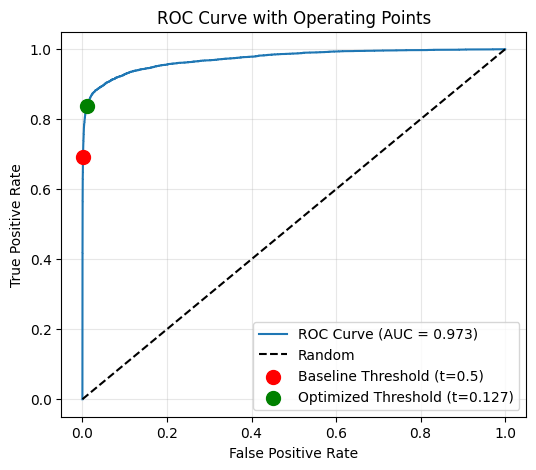

In [113]:
from sklearn.metrics import roc_auc_score
plt.figure(figsize=(6, 5))
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.plot(fpr_test, tpr_test, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Mark the operating points
plt.scatter(fpr_base, tp_base/(tp_base + fn_base), color='red', s=100, 
           label=f'Baseline Threshold (t=0.5)', zorder=5)
plt.scatter(fpr_opt, tp_opt/(tp_opt + fn_opt), color='green', s=100, 
           label=f'Optimized Threshold (t={best_threshold:.3f})', zorder=5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Operating Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()